# TerraMind patch embeddings on openEO

This notebook shows how to run [TerraMind 1.0](https://github.com/IBM/terramind) (IBM + ESA's any-to-any generative foundation model for Earth Observation) inside an openEO UDF to produce a **768-band patch embedding cube** from Sentinel-2 L2A + Sentinel-1 GRD, and how to sanity-check that cube with an unsupervised K-means clustering.

See [README.md](./README.md) for architecture and caveats.

## Why materialise the embedding as its own cube?

The pipeline treats the foundation-model output as an explicit, reusable artefact rather than fusing it with a downstream task:

- **Reusable intermediate.** The 768-band embedding cube is task-agnostic. Once produced, the same cube can feed a land-cover classifier, a crop-type model, a change-detection routine, or a similarity-search index.
- **Trade-off you should know.** Materialising a 768-band intermediate is more I/O than fusing embedding + downstream model into a single UDF. For a single downstream task at scale you'd probably fuse them; for exploring many downstream tasks on the same AOI, the split pays off after the second one.
- **Downstream is deliberately out of scope here.** A follow-up notebook can plug the embedding into `fit_class_random_forest` / `predict_random_forest` (see [`../DynamicLandCoverMapping`](../DynamicLandCoverMapping) for that pattern) or a custom UDF classifier.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import openeo
import xarray as xr

## Connect to the backend

Using the [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu/) openEO endpoint, which hosts Sentinel-1, Sentinel-2 and ESA WorldCover.

In [2]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## Define AOI and temporal extent

We pick a small AOI in Belgium and the year **2018** so we can reuse the LUCAS Copernicus 2018 reference labels. TerraMind operates on 224×224 spatial tiles at ~10 m, so an extent a few km on a side is plenty to demonstrate the pipeline.

In [ ]:
# ~4.5 x 4.5 km (2 x 2 TerraMind tiles) around Namur, Belgium: the confluence
# of the Meuse and Sambre rivers, cliffs, forest, farmland and town all inside.
spatial_extent = {
    "west": 4.840,
    "south": 50.440,
    "east": 4.900,
    "north": 50.482,
    "crs": 4326,
}

temporal_extent = ["2018-06-01", "2018-08-31"]

CLOUD_COVER = 60
S2_BANDS = ["B01", "B02", "B03", "B04", "B05", "B06", "B07",
            "B08", "B8A", "B09", "B11", "B12"]


## Load Sentinel-2 L2A and Sentinel-1 GRD, then build a cloud-masked annual composite

TerraMind's backbone is single-timestep, so we reduce the temporal period to one image per pixel with a temporal median.

For Sentinel-2 we first build an SCL-derived dilation mask (`to_scl_dilation_mask`) and then mask the reflectance cube before temporal aggregation. This is more robust than relying only on scene-level cloud filters.

If your backend exposes a BAP workflow, you can swap this block for a BAP-based composite instead.

TerraMind expects 12 S2 L2A bands in a specific order; we load exactly those. S1 GRD is loaded as VV + VH in linear power.

In [ ]:
def build_input_cube(extent):
    """Return a TerraMind-ready cube (12 S2 L2A bands + VV/VH) for the AOI."""
    scl = connection.load_collection(
        collection_id="SENTINEL2_L2A",
        spatial_extent=extent,
        temporal_extent=temporal_extent,
        bands=["SCL"],
        properties={"eo:cloud_cover": lambda x: x.lte(CLOUD_COVER)},
    )
    cloud_mask = scl.process(
        "to_scl_dilation_mask",
        data=scl,
        kernel1_size=17,
        kernel2_size=77,
        mask1_values=[2, 4, 5, 6, 7],
        mask2_values=[3, 8, 9, 10, 11],
        erosion_kernel_size=3,
    )
    s2 = (
        connection.load_collection(
            collection_id="SENTINEL2_L2A",
            spatial_extent=extent,
            temporal_extent=temporal_extent,
            bands=S2_BANDS,
            properties={"eo:cloud_cover": lambda x: x.lte(CLOUD_COVER)},
        )
        .mask(cloud_mask)
        .reduce_dimension(dimension="t", reducer="median")
    )
    s1 = (
        connection.load_collection(
            "SENTINEL1_GRD",
            spatial_extent=extent,
            temporal_extent=temporal_extent,
            bands=["VV", "VH"],
        )
        .sar_backscatter(coefficient="sigma0-ellipsoid")
        .reduce_dimension(dimension="t", reducer="median")
    )
    return s2.merge_cubes(s1)


merged = build_input_cube(spatial_extent)

input_job = merged.save_result(format="NetCDF").execute_batch(
    "results/terramind_input.nc",
    title="TerraMind input cube (ONNX)")


(np.float64(-0.5), np.float64(437.5), np.float64(477.5), np.float64(-0.5))

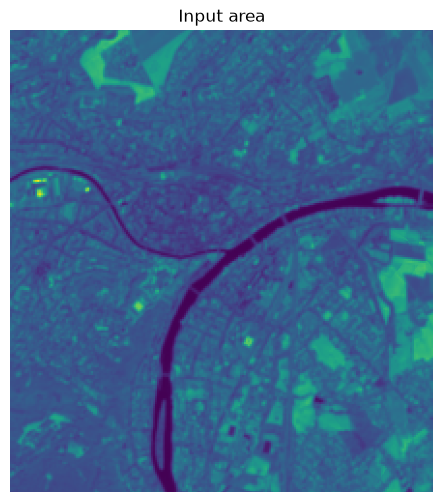

In [ ]:
input_ds = xr.open_dataset("results/terramind_input.nc")
if "crs" in input_ds.variables:
    input_ds = input_ds.drop_vars("crs")

input_arr = input_ds.to_array(dim="bands").squeeze()   # (bands, y, x)


plt.figure(figsize=(6, 6))
plt.imshow(input_arr[10])
plt.title("Input area")
plt.axis("off")

## Step 1: Run TerraMind as a UDF to produce the embedding cube

The UDF ([udf_terramind_embedding.py](./udf_terramind_embedding.py)) runs the TerraMind encoder on 224×224 windows via `apply_neighborhood` and returns a **768-band embedding cube on the input pixel grid**. TerraMind is a ViT with 16 px patches, so each 224×224 tile natively yields a 14×14 grid of 768-d tokens (one embedding per 16×16 pixel block, ~160 m spatial support). 

**No PyTorch, no TerraTorch in the sandbox.** The encoder is exported to ONNX **once, offline** with [`export_terramind_to_onnx.py`](./export_terramind_to_onnx.py); the UDF only needs `onnxruntime` at runtime (same dependency archive pattern as [`../OnnxMLInference`](../OnnxMLInference)). Standardization is baked into the ONNX graph, so raw S2 L2A DN + S1 linear power go straight in.

Both the `.onnx` graph and its `.onnx.data` external-weights sidecar are shipped to the backend inside a single zip via the `udf-dependency-archives` job option (`terramind_v1_base_onnx.zip#terramind_onnx` → extracted to a `terramind_onnx/` folder in the sandbox). No runtime HTTPS download from the UDF.

Before running this cell:

1. On a machine with TerraTorch installed, run
   `python export_terramind_to_onnx.py --model terramind_v1_base --out terramind_v1_base_encoder.onnx`

2. Zip the resulting `terramind_v1_base_encoder.onnx` **together with** `terramind_v1_base_encoder.onnx.data` under a `terramind_v1_base_onnx/` folder inside `terramind_v1_base_onnx.zip` (this matches the `onnx_dir` / `onnx_filename` context set below; adjust either side if your zip layout differs).
3. Upload the zip to a location the backend can reach over HTTPS and set `TERRAMIND_ONNX_ARCHIVE` below.

In [ ]:
# Zip must contain terramind_v1_base_encoder.onnx + .onnx.data at its root.
# The '#terramind_onnx' alias is the folder name the archive extracts to in
# the UDF sandbox, and matches the default context["onnx_dir"] in the UDF.
TERRAMIND_ONNX_ARCHIVE = (
    "https://s3.waw3-1.cloudferro.com/project_dependencies/"
    "terramind_v1_base_onnx.zip#terramind_onnx"
)

embedding_udf = openeo.UDF.from_file(
    "udf_terramind_embedding.py",
    context={
        "onnx_dir": "terramind_onnx/terramind_v1_base_onnx",
        "onnx_filename": "terramind_v1_base_encoder.onnx",
    },
)

embedding_cube = merged.apply_neighborhood(
    process=embedding_udf,
    size=[
        {"dimension": "x", "value": 176, "unit": "px"},
        {"dimension": "y", "value": 176, "unit": "px"},
    ],
    overlap=[
        {"dimension": "x", "value": 24, "unit": "px"},
        {"dimension": "y", "value": 24, "unit": "px"},
    ],
)

job_options = {
    # 768-band tiles have to be pushed through the executor JVM on their way
    # to NetCDF, so the JVM heap needs headroom; running one tile per JVM at
    # a time keeps peak heap usage bounded regardless of AOI size.
    "driver-memory": "8g",
    "executor-memory": "6g",
    "executor-memoryOverhead": "4g",
    "python-memory": "6g",
    "executor-cores": 1,
    "udf-dependency-archives": [
        # onnxruntime archive — same one used by ../OnnxMLInference
        "https://s3.waw3-1.cloudferro.com/project_dependencies//onnx_deps_python311.zip#onnx_deps",
        # TerraMind encoder: .onnx + .onnx.data zipped together
        TERRAMIND_ONNX_ARCHIVE,
    ],
}

embedding_job = embedding_cube.save_result(format="NetCDF").execute_batch(
    "results/terramind_embedding.nc",
    title="TerraMind embedding cube (ONNX)",
    job_options=job_options,
)

### Sanity-check the embedding (K-means on tokens)

Cluster the 768-d token vectors with K-means and colour each 16×16 patch by its cluster label. Coherent blobs of colour = the embedding is picking up land-cover structure with zero supervision.

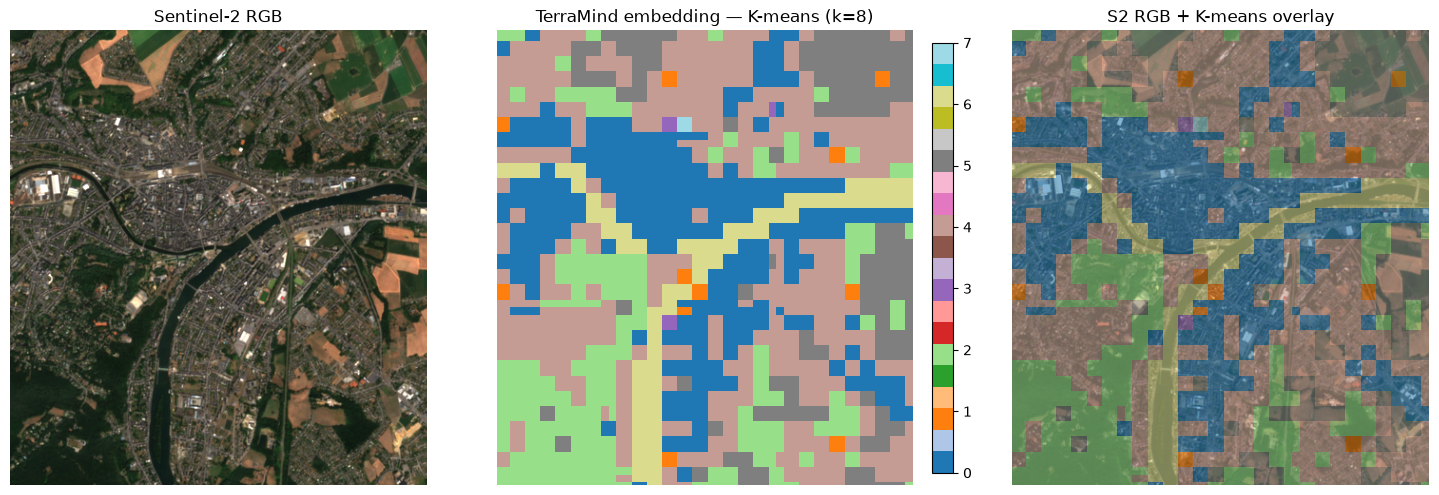

In [20]:
from sklearn.cluster import KMeans

emb_ds = xr.open_dataset("results/terramind_embedding.nc")
if "crs" in emb_ds.variables:
    emb_ds = emb_ds.drop_vars("crs")

emb_arr = emb_ds.to_array(dim="bands").squeeze()   # (bands, y, x)

n_clusters = 8
n_bands, h_tok, w_tok = emb_arr.shape
tokens = emb_arr.values.reshape(n_bands, -1).T     # (pixels, 768)
labels = KMeans(n_clusters=n_clusters, n_init=10, random_state=0).fit_predict(tokens)
label_map = labels.reshape(h_tok, w_tok)

# Build an S2 RGB reference from the input cube for the overlay plot.
# Bands are ordered by S2_BANDS: B04=idx 3, B03=idx 2, B02=idx 1.
rgb = np.stack([input_arr[3].values, input_arr[2].values, input_arr[1].values], axis=-1)
rgb = np.clip(rgb / 3000.0, 0, 1)   # simple linear stretch for L2A reflectance

# Upsample the token-resolution label map to the S2 pixel grid so we can overlay.
scale_y = rgb.shape[0] // h_tok
scale_x = rgb.shape[1] // w_tok
label_up = np.kron(label_map, np.ones((scale_y, scale_x), dtype=label_map.dtype))
label_up = label_up[: rgb.shape[0], : rgb.shape[1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 RGB")
axes[0].axis("off")

im = axes[1].imshow(label_map, cmap="tab20", interpolation="nearest",
                    vmin=0, vmax=max(n_clusters - 1, 1))
axes[1].set_title(f"TerraMind embedding — K-means (k={n_clusters})")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(rgb)
axes[2].imshow(label_up, cmap="tab20", interpolation="nearest",
               vmin=0, vmax=max(n_clusters - 1, 1), alpha=0.55)
axes[2].set_title("S2 RGB + K-means overlay")
axes[2].axis("off")

plt.tight_layout()


## Conclusion

We used openEO to load Sentinel-2 L2A + Sentinel-1 GRD, ran the pretrained TerraMind backbone as an **ONNX model inside a UDF** (no PyTorch or TerraTorch in the sandbox — just `onnxruntime`) to produce a 768-band embedding cube, and sanity-checked it with an unsupervised K-means: coherent blobs of colour tracking the river, forest, farmland and built-up areas in the S2 RGB confirm the embedding is picking up land-cover structure with zero supervision.

Materialising the embedding as its own cube makes it a **reusable intermediate**: the same NetCDF can feed a land-cover RF, a crop-type classifier, or a change-detection routine without re-running TerraMind. For single-shot production at scale you'd fuse embedding + downstream model into one UDF; for research and multi-task exploration on a fixed AOI, the split is the point.

### Where to go next

- **Fine-tune TerraMind.** Use [TerraTorch](https://torchgeo.org/terratorch/stable/guide/terramind/) offline (`terratorch fit`) or LoRA adapters to specialize the encoder to your task, re-export to ONNX with the same script, and point `TERRAMIND_ONNX_ARCHIVE` at the new zip. Nothing else in the notebook changes.
- **Thinking-in-Modalities.** TerraMind can hallucinate an intermediate modality (e.g. LULC) to boost downstream performance — export the `terramind_v1_base_tim` variant via `export_terramind_to_onnx.py` and swap it in.
- **Add a downstream classifier.** Feed the embedding cube into `aggregate_spatial` + `fit_class_random_forest` + `predict_random_forest` against a reference dataset like LUCAS (see [`../DynamicLandCoverMapping`](../DynamicLandCoverMapping)), or plug in your own UDF (ONNX, sklearn, PyTorch) for downstream applications.

